<a href="https://colab.research.google.com/github/deshmukhvaishnavi04/celebal-internship/blob/main/week6_vaishnavi_deshmukh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Image Denoising Using Deep Learning Autoencoder on MNIST Dataset

#Objective

The objective of this project is to develop a Deep Learning Denoising Autoencoder capable of removing artificial noise from handwritten digit images of the MNIST dataset. The model learns to reconstruct clean images from noisy inputs by training an encoder-decoder architecture. This demonstrates the application of autoencoders in image restoration and denoising tasks.



###Import Required Libraries

In [20]:

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model


###Load the MNIST Dataset

In [37]:
# Load MNIST dataset
(x_train, _), (x_test, _) = mnist.load_data()

print("Training Images:", x_train.shape)
print("Testing Images:", x_test.shape)


Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)


###Display Sample Images

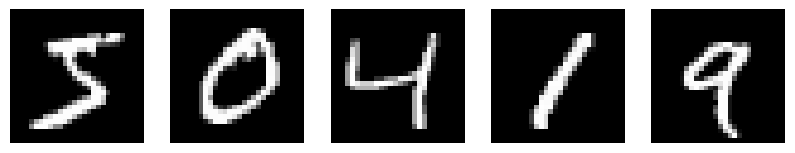

In [22]:
plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis("off")

plt.show()

###Preprocess the Dataset

Normalize the images.

In [23]:

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


Flatten the images.

In [24]:

x_train = x_train.reshape((len(x_train),784))
x_test = x_test.reshape((len(x_test),784))

print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


###Add Artificial Noise

In [25]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy,0.,1.)
x_test_noisy = np.clip(x_test_noisy,0.,1.)


###Display Noisy Images

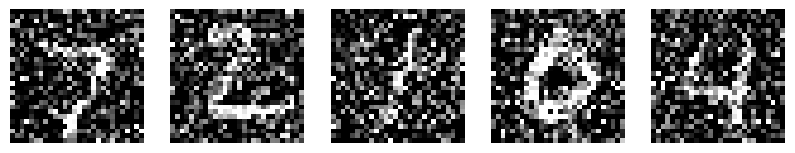

In [26]:
plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.axis("off")

###Build the Denoising Autoencoder

In [27]:

input_img = Input(shape=(784,))


*Encoder*

In [28]:

encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)


Decoder

In [29]:

decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(784, activation='sigmoid')(decoded)

Create Model

In [30]:

autoencoder = Model(input_img, decoded)


Compile the Model

In [31]:

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)


###View Model Summary

In [32]:

autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,192 (852.31 KB)

 Trainable params: 218,192 (852.31 KB)

 Non-trainable params: 0 (0.00 B)


###Train the Model

In [33]:


history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.2527 - val_loss: 0.1826
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1661 - val_loss: 0.1530
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1481 - val_loss: 0.1419
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1401 - val_loss: 0.1363
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1350 - val_loss: 0.1318
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 0.1311 - val_loss: 0.1286
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1283 - val_loss: 0.1267
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1261 - val_loss: 0.1243
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1242 - val_loss: 0.1227
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1226 - val_loss: 0.1216
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.1213 - val_loss: 0.1201
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 


###Plot Training and Validation Loss

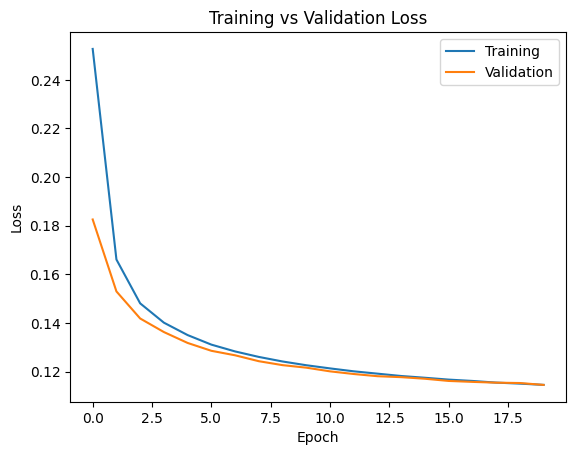

In [34]:


plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Training","Validation"])

plt.show()


###Generate Denoised Images

In [35]:


decoded_images = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


###Compare Original, Noisy and Denoised Images

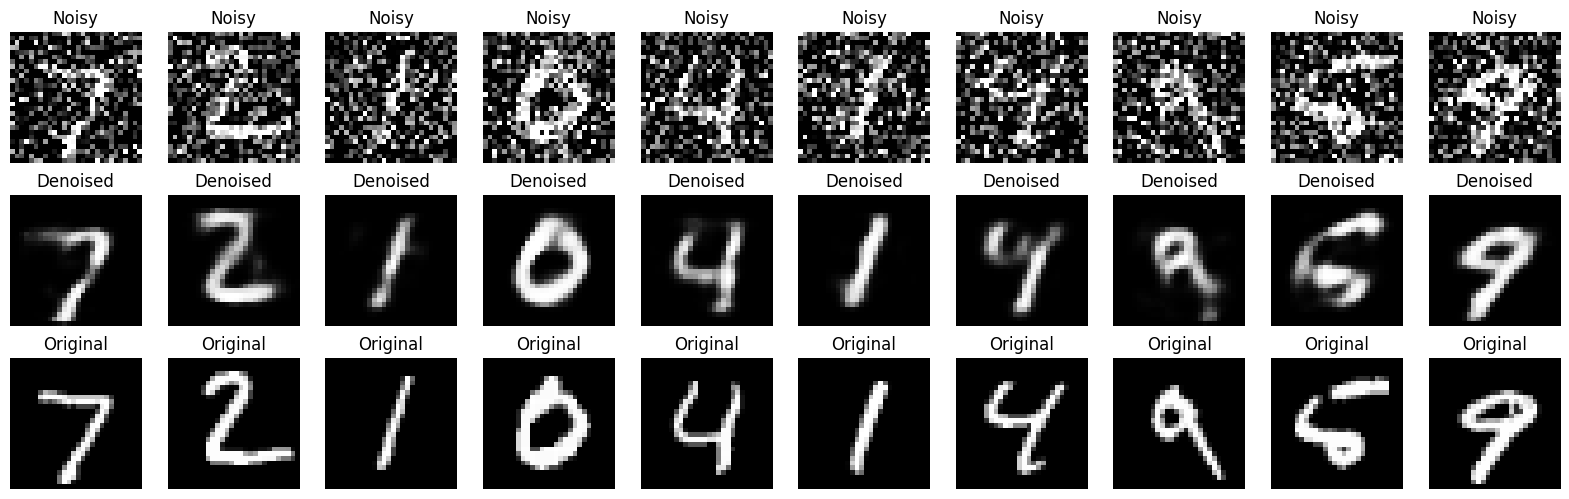

In [36]:
n = 10

plt.figure(figsize=(20,6))

for i in range(n):

    # Noisy Image
    ax = plt.subplot(3,n,i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Denoised Image
    ax = plt.subplot(3,n,i+1+n)
    plt.imshow(decoded_images[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

    # Original Image
    ax = plt.subplot(3,n,i+1+2*n)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

plt.show()


###
Observations

The MNIST dataset was successfully loaded and preprocessed. Pixel values were normalized between 0 and 1, improving training stability. Artificial Gaussian noise was added to create noisy input images. The autoencoder learned to reconstruct clean images from noisy inputs. The denoised images preserved the handwritten digit structure while removing most of the added noise. Training and validation loss decreased steadily, indicating that the model learned effectively. The reconstructed images were visually similar to the original images, demonstrating successful denoising

###Results

Successfully loaded and preprocessed the MNIST dataset. Added Gaussian noise to generate noisy input images. Built and trained a Dense Autoencoder using TensorFlow/Keras. Generated denoised outputs from noisy test images. Compared original, noisy, and reconstructed images using visualization. The model effectively reduced noise while preserving the essential features of handwritten digits.

###
Conclusion

In this project, a Deep Learning Denoising Autoencoder was developed using the MNIST dataset. The model was trained to reconstruct clean handwritten digit images from artificially noisy inputs. The encoder learned compact image features, while the decoder successfully restored the images with minimal noise. The results demonstrate that autoencoders are effective for image denoising and image restoration tasks. This project also highlights the practical application of deep learning in computer vision.